Optimal trading strategy implementation (Dynamic Trading)

In [342]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm

Importing data for different commodities 

In [470]:
tickers = {
    'Gold': 'GC=F',
    'Silver': 'SI=F',
    'Crude Oil': 'CL=F',
    'Natural Gas': 'NG=F',
    # 'Copper': 'HG=F',
    # 'Heating Oil': 'HO=F',
    # 'Gasoline': 'RB=F',
    # 'Brent Crude': 'BZ=F',
    # 'Coffee': 'KC=F',
    # 'Cocoa': 'CC=F',
    # 'Sugar': 'SB=F',
    # 'Cotton': 'CT=F',
    # 'Corn': 'ZC=F',
    # 'Wheat': 'ZW=F',
    # 'Soybeans': 'ZS=F',
}


multipliers = {
    'GC=F': 100,
    'SI=F': 5000,
    'CL=F': 1000,
    'NG=F': 10000,
#     'HG=F': 25000,
#     'HO=F': 42000,
#     'RB=F': 42000,
#     'BZ=F': 1000,
#     'KC=F': 37500,
#     'CC=F': 10,
#     'SB=F': 112000,
#     'CT=F': 50000,
#     'ZC=F': 5000,
#     'ZW=F': 5000,
#     'ZS=F': 5000,
}


start = '2008-01-01'
end = '2019-01-01'

In [471]:
commodities_data =  yf.download(list(tickers.values()), start=start, end=end)

/tmp/ipykernel_3736/2953684191.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  commodities_data =  yf.download(list(tickers.values()), start=start, end=end)
[*********************100%***********************]  4 of 4 completed


In [472]:
price_df = commodities_data['Close'].mul(pd.Series(multipliers), axis=1).dropna()

In [473]:
dP = price_df.diff().dropna()

In [474]:
dP.to_csv('data/commodities_price_changes.csv')

Calculating the different parameters in the strategy

In [475]:
dP = pd.read_csv('data/commodities_price_changes.csv', index_col=0)

In [476]:
### 5D, 1Y, 5Y PREDICTORS 

f_5d = (dP.rolling(window=5).mean() / dP.rolling(window=5).std(ddof=0)).shift(1).dropna()
f_1y = (dP.rolling(window=252).mean() / dP.rolling(window=252).std(ddof=0)).shift(1).dropna()
f_5y = (dP.rolling(window=1260).mean() / dP.rolling(window=1260).std(ddof=0)).shift(1).dropna()

dP = dP.loc[f_5d.index.intersection(f_1y.index).intersection(f_5y.index)]

In [477]:
### SIGMA AND ITS INVERSE

vol = dP.std(ddof=1)
corr = dP.corr()

# 50% correlation shrinkage
I = np.eye(len(corr))
corr_shrunk = 0.5 * corr + 0.5 * pd.DataFrame(I, index=corr.index, columns=corr.columns)

# Rebuild covariance with unchanged vol
Sigma = np.outer(vol, vol) * corr_shrunk.values
Sigma = pd.DataFrame(Sigma, index=dP.columns, columns=dP.columns)
Sigma_inv = pd.DataFrame(np.linalg.inv(Sigma), index=dP.columns, columns=dP.columns)

In [478]:
### PREDICTORS' COEFFICIENTS USING OLS

df = pd.DataFrame({
    'r':  dP.shift(-1).stack(),      # r_{t+1}
    'f_5d': f_5d.stack(),
    'f_1y': f_1y.stack(),
    'f_5y': f_5y.stack(),
})

df = df.dropna()

X = sm.add_constant(df[['f_5d', 'f_1y', 'f_5y']])
y = df['r']

model = sm.OLS(y, X).fit()

In [479]:
Bf = (pd.Series(model.params) * X).sum(axis=1).unstack(level=1) 
ind = dP.index.intersection(Bf.index)
dP = dP.loc[ind]     

# Cholesky factor of Σ to generate correlated noise
chol = np.linalg.cholesky(Sigma.values)

# Generate Gaussian noise with mean 0 and covariance Σ for each day
np.random.seed(42)  # for reproducibility
noise = np.random.randn(len(Bf), len(tickers.values())) @ chol

noise_df = pd.DataFrame(noise, index=Bf.index, columns=Bf.columns)

# Final simulated returns r_t = μ_t + ε_t
r = Bf + noise_df

In [531]:
### ARTICLE VALUES FOR GAMMA AND RHO

gamma = 1e-7
rho = 1 - np.exp(-0.02 / 260)

In [532]:
### CALCULATING LAMBDA 

sigma = dP.std(ddof=1)  # $ volatility per contract

f = 0.0159     # 1.59% of daily volume
impact = 0.001 # 0.10% of price

mean_price = price_df.loc[dP.index].mean()                 
mean_volume = commodities_data['Volume'].loc[dP.index].mean() 

lambda_asset = 2 * (impact * mean_price) / (f * mean_volume * (sigma**2))

lambda_tc = float(lambda_asset.mean())
lambda_high = lambda_asset.max()

Implementing the different strategies 

In [533]:
dates = dP.index
cols = dP.columns
assets = tickers.values()
N = len(assets)

In [534]:
### MARKOWITZ
    
markowitz_pos = (Bf.values @ Sigma_inv.values.T) / gamma
markowitz_pos = pd.DataFrame(markowitz_pos, index=dates, columns=cols)

In [535]:
### STATIC

alpha_static = gamma / (gamma + lambda_high)

static_pos = pd.DataFrame(index=dates, columns=cols, dtype=float)
x_prev = np.zeros(len(cols))
    
for t in dates:
    m_t = markowitz_pos.loc[t].values
    x_t = x_prev + alpha_static * (m_t - x_prev)
    static_pos.loc[t] = x_t
    x_prev = x_t

In [536]:
### DYNAMIC STRATEGY    

# Compute 'a' and trading speed a/λ
rho_bar = 1 - rho

a_num = -(gamma * rho_bar + lambda_high * rho)
disc = (gamma * rho_bar + lambda_high * rho)**2 + 4 * gamma * lambda_high * (rho_bar**2)
a = (a_num + np.sqrt(disc)) / (2 * rho_bar)

trade_speed = a / lambda_high    # TRADING SPEED

# Mean-reversion speeds from the article

phi_5d = 0.2519
phi_1y = 0.0034
phi_5y = 0.0010

beta0   = model.params['const']
beta_5d = model.params['f_5d']
beta_1y = model.params['f_1y']
beta_5y = model.params['f_5y']

beta_dyn_5d = beta_5d / (1 + phi_5d * a / gamma)
beta_dyn_1y = beta_1y / (1 + phi_1y * a / gamma)
beta_dyn_5y = beta_5y / (1 + phi_5y * a / gamma)
# constant has no mean reversion so no scaling
beta_dyn_0 = beta0

# Align predictors with r_t index
f5 = f_5d.loc[dates, assets]
f1 = f_1y.loc[dates, assets]
f5y = f_5y.loc[dates, assets]

# Dynamic expected return r_t^dyn
r_dyn = (beta_dyn_0
          + beta_dyn_5d * f5
          + beta_dyn_1y * f1
          + beta_dyn_5y * f5y)

# Aim portfolio
aim_dyn = (r_dyn.values @ Sigma_inv.values.T) / gamma
aim_dyn = pd.DataFrame(aim_dyn, index=dates, columns=assets)

# Recursive computation of dynamic positions 

dynamic_pos = pd.DataFrame(index=dates, columns=assets, dtype=float)
x_prev = np.zeros(N)

for t in dates:
    q_t = aim_dyn.loc[t].values
    x_t = (1 - trade_speed) * x_prev + trade_speed * q_t
    dynamic_pos.loc[t] = x_t
    x_prev = x_t

In [537]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      r   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     7.190
Date:                Fri, 14 Nov 2025   Prob (F-statistic):           8.16e-05
Time:                        23:49:53   Log-Likelihood:                -51369.
No. Observations:                6016   AIC:                         1.027e+05
Df Residuals:                    6012   BIC:                         1.028e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -60.9681     19.043     -3.202      0.001     -98.299     -23.637
f_5d          82.7567     25.441      3.253      0.001      32.883     132.630
f_1y        -416.6806    322.628     -1.292      0.197   -1049.148     215.787
f_5y       -3233.2853    959.549     -3.370      0.001   -5114.346   -1352.225
==============================================================================
Omnibus:                     1531.810   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            30170.025
Skew:                          -0.721   Prob(JB):                         0.00
Kurtosis:                      13.876   Cond. No.                         60.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [538]:
1 + phi_1y * a / gamma

np.float64(1.0152023602341391)

Simulating the portfolios 

In [539]:
def position_pnl(position, dP):
    common_idx = dP.index.intersection(position.index)
    position = position.loc[common_idx]
    dP_ = dP.loc[common_idx]
    pnl = (position.shift(1) * dP_).sum(axis=1)
    return pnl.dropna()

pnl_markowitz = position_pnl(markowitz_pos, dP)
pnl_static    = position_pnl(static_pos, dP)
pnl_dynamic   = position_pnl(dynamic_pos, dP)

<Axes: xlabel='Date'>

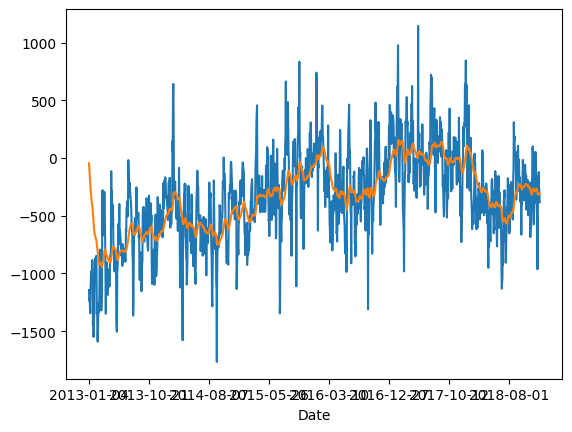

In [540]:
markowitz_pos['GC=F'].plot()
static_pos['GC=F'].plot()

In [ ]:
plt.figure()
markowitz_pos['GC=F'].plot()
dynamic_pos['CL=F'].plot()


NameError: name 'plt' is not defined

In [497]:
def annualized_sharpe(pnl_series):
    daily_mean = pnl_series.mean()
    daily_std  = pnl_series.std(ddof=1)
    return (daily_mean / daily_std) * np.sqrt(260)

sharpe_m = annualized_sharpe(pnl_markowitz)
sharpe_s = annualized_sharpe(pnl_static)
sharpe_d = annualized_sharpe(pnl_dynamic)

print("Annualized Sharpe ratios:")
print("Markowitz  :", sharpe_m)
print("Static     :", sharpe_s)
print("Dynamic    :", sharpe_d)


Annualized Sharpe ratios:
Markowitz  : 1.480045057859042
Static     : 1.0580492246808235
Dynamic    : 0.9165151276107002
